![](https://github.com/destination-earth/DestinE-DataLake-Lab/blob/main/img/DestinE-banner.jpg?raw=true)

# DEDL - HDA Climate DT Parameter Plotter - Tutorial

**Author**: EUMETSAT <br>
**Copyright**: 2024 EUMETSAT <br>
**Licence**: MIT <br>
**Credit**: Earthkit and HDA Polytope used in this context are both packages provided by the European Centre for Medium-Range Weather Forecasts (**ECMWF**).

**DEDL Harmonised Data Access** is used in this example to access and plot Climate DT parameter.</br>


[Documentation DestinE DataLake HDA](https://destine-data-lake-docs.data.destination-earth.eu/en/latest/dedl-discovery-and-data-access/dedl-discovery-and-data-access.html)

[Climate DT overview](https://confluence.ecmwf.int/display/DDCZ/Climate+DT+overview)








## Import the required packages

In [1]:
pip install --quiet --upgrade destinelab


[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Import the Climate DT parameter & scenario dictionary

In [2]:
from destinelab import climate_dt_dictionary
import ipywidgets as widgets
import json
import datetime

import importlib.metadata

In [3]:
import numpy as np
from netCDF4 import Dataset
import  matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import warnings
import datetime
import time # for sleep
import os.path # for basename
import glob
import xarray as xr
from numpy import savetxt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from PIL import Image
from global_land_mask import globe
from scipy.interpolate import griddata
import matplotlib.cm as cm
import matplotlib.colors as colors
from rasterio.transform import from_origin

/home/ubuntu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Climate DT parameter selection (we limit the plotting to one parameter)

In [4]:
# Create search box
search_box = widgets.Text(placeholder='Search by parameter name', description='Search:', disabled=False)

# Create dropdown to select entry
entry_dropdown = widgets.Dropdown(
    options=[(entry['paramName'], i) for i, entry in enumerate(climate_dt_dictionary.climateDT_params)],
    description='Select Entry:'
)

def filter_entries(search_string):
    return [(entry['paramName'], i) for i, entry in enumerate(climate_dt_dictionary.climateDT_params) if search_string.lower() in entry['paramName'].lower()]

def on_search_change(change):
    search_string = change.new
    if search_string:
        filtered_options = filter_entries(search_string)
        entry_dropdown.options = filtered_options
    else:
        entry_dropdown.options = [(entry['paramName'], i) for i, entry in enumerate(climate_dt_dictionary.climateDT_params)]

search_box.observe(on_search_change, names='value')

# Display widgets
display(search_box, entry_dropdown)

def get_selected_entry():
    return entry_dropdown.value


Text(value='', description='Search:', placeholder='Search by parameter name')

Dropdown(description='Select Entry:', options=(('Total column cloud liquid water', 0), ('Total column cloud ic…

In [6]:
# Print the details of the parameter (Polytope convention):
selected_index = get_selected_entry()
selected_entry = climate_dt_dictionary.climateDT_params[selected_index]
print(json.dumps(selected_entry,indent=4))

{
    "param": "263000",
    "paramName": "Time-mean sea ice thickness",
    "shortName": "avg_sithick",
    "unit": "m",
    "encoding": "mean",
    "isNemo": "IFS-NEMO",
    "isIcon": "ICON",
    "isFESOM": "IFS-FESOM",
    "stream": "clte",
    "type": "fc",
    "time": "Daily",
    "levtype": "o2d",
    "levelist": ""
}


## Choose now the Scenario from which we want to obtain the Climate Parameter

In [7]:
# Create dropdown to select scenario
scenario_dropdown = widgets.Dropdown(
    options=[(f"{entry['experiment']} - {entry['model']} - {resolution}", (i, resolution)) for i, entry in enumerate(climate_dt_dictionary.climateDT_scenario) for resolution in entry['resolution']],
    description='Scenario:'
)

# Function to generate hourly slots
def generate_hourly_slots():
    hours = []
    for hour in range(0, 24):
        for minute in range(0, 60, 60):  # Step by 60 minutes (1 hour)
            hours.append(datetime.time(hour, minute))
    return hours

# Create dropdown to select hour
hourly_slots = generate_hourly_slots()
hour_dropdown = widgets.Dropdown(options=[(str(slot), slot) for slot in hourly_slots], description='Select Hour:', disabled=False)

# Create date picker widgets
start_date_picker = widgets.DatePicker(description='Start Date:', disabled=False)

def on_scenario_change(change):
    selected_index, selected_resolution = change.new
    selected_sc_entry = climate_dt_dictionary.climateDT_scenario[selected_index]
    date_from = datetime.datetime.strptime(selected_sc_entry['dateFrom'], '%m/%d/%Y').date()
    start_date_picker.max = None
    start_date_picker.min = date_from
    start_date_picker.max = datetime.datetime.strptime(selected_sc_entry['dateTo'], '%m/%d/%Y').date()
    start_date_picker.value = date_from

scenario_dropdown.observe(on_scenario_change, names='value')

# Set initial values directly
selected_sc_entry = climate_dt_dictionary.climateDT_scenario[0]
# Convert dateFrom string to date object
date_from = datetime.datetime.strptime(selected_sc_entry['dateFrom'], '%m/%d/%Y').date()

# Set initial values directly
start_date_picker.min = date_from
start_date_picker.max = datetime.datetime.strptime(selected_sc_entry['dateTo'], '%m/%d/%Y').date()
start_date_picker.value = date_from

# Display widgets
if selected_entry["time"] == "Hourly":
    display(scenario_dropdown, start_date_picker, hour_dropdown)
else:
    display(scenario_dropdown, start_date_picker)

def get_selected_values():
    selected_scenario_index, selected_resolution = scenario_dropdown.value
    selected_scenario = climate_dt_dictionary.climateDT_scenario[selected_scenario_index]
    selected_start_date = start_date_picker.value
    selected_end_date = "" # end_date_picker.value
    selected_hour = "00:00:00"
    if selected_entry["time"] == "Hourly":
        selected_hour = hour_dropdown.value
        
    return selected_scenario_index, selected_scenario, selected_resolution, selected_start_date, selected_end_date, selected_hour

# Example usage:
selected_scenario_index, selected_scenario, selected_resolution, selected_start_date, selected_end_date, selected_hour = get_selected_values()


Dropdown(description='Scenario:', options=(('ssp3-7.0 - IFS-NEMO - high', (0, 'high')), ('ssp3-7.0 - IFS-NEMO …

DatePicker(value=datetime.date(2020, 1, 1), description='Start Date:', max=datetime.date(2039, 12, 30), min=da…

Handle different Levels to be selected (if any)

In [8]:
# Define a global variable
global global_widget
global_widget = None

if selected_entry["levelist"] != "":
    # Convert levelist string to list of integers
    levelist = list(map(int, selected_entry["levelist"].split('/')))
    if(selected_scenario['model']=='IFS-NEMO'):
        levelist = levelist + [73,74,75]

      
    # Create a function to generate the widget based on the selection mode
    def generate_widget(selection_mode):
        global global_widget
        if selection_mode == 'Single':
            global_widget = widgets.Dropdown(options=levelist, description='Select level:')
            return global_widget
        elif selection_mode == 'Multiple':
            global_widget = widgets.SelectMultiple(options=levelist, description='Select levels:')
            return global_widget

    # Create a dropdown widget to choose selection mode
    selection_mode_dropdown = widgets.Dropdown(options=['Single', 'Multiple'], description='Selection Mode:')

    # Create an output widget to display the selected option(s)
    output = widgets.Output()

    # Function to display the widget based on the selection mode
    def display_widget(selection_mode):
        output.clear_output()
        with output:
            display(generate_widget(selection_mode))

    # Define a function to handle the change in selection mode
    def on_dropdown_change(change):
        display_widget(change.new)

    # Register the function to handle dropdown changes
    selection_mode_dropdown.observe(on_dropdown_change, names='value')

    # Display the widgets
    display(selection_mode_dropdown, output)

    # Display the initial widget based on default selection mode
    display_widget('Single')

In [9]:
# Function to convert tuple or single integer to string separated by "/"
def convert_to_string(input):
    if isinstance(input, tuple):
        return '/'.join(map(str, input))
    elif isinstance(input, int):
        return str(input)
    else:
        return None  # Handle other types if needed

levlInput = ""
if global_widget != None:
    # Test cases
    levlInput = convert_to_string(global_widget.value)


In [10]:
hourchoice4 = '{shour}00'.format(shour = str(get_selected_values()[5]).split(":")[0])

filter_params = {
  "class": "d1",             # fixed 
  "dataset": "climate-dt",   # fixed climate-dt access
  "activity" : get_selected_values()[1]["activity"],
  "experiment" : get_selected_values()[1]["experiment"].upper(),
  "model": get_selected_values()[1]["model"],
  "generation": "1",         # fixed Specifies the generation of the dataset, which can be incremented as required (latest is 1)
  "realization": "1",        # fixed Specifies the climate realization. Default 1. Based on perturbations of initial conditions
  "resolution": get_selected_values()[2],      # standard/ high 
  "expver": "0001",          # fixed experiment version 
  "stream": selected_entry["stream"],
  "time": hourchoice4,            # choose the hourly slot(s)
  "type": "fc",              # fixed forecasted fields
  "levtype": selected_entry["levtype"],  
  "levelist": str(levlInput),  
  "param": str(selected_entry["param"]),  
}

# Print the result in JSON format
datechoice = "{fname}T{shour}Z".format(fname = get_selected_values()[3], shour = get_selected_values()[5] )
print("datechoice = ", datechoice)
print(json.dumps(filter_params, indent=4))


datechoice =  2020-01-01T00:00:00Z
{
    "class": "d1",
    "dataset": "climate-dt",
    "activity": "ScenarioMIP",
    "experiment": "SSP3-7.0",
    "model": "IFS-NEMO",
    "generation": "1",
    "realization": "1",
    "resolution": "high",
    "expver": "0001",
    "stream": "clte",
    "time": "0000",
    "type": "fc",
    "levtype": "o2d",
    "levelist": "",
    "param": "263000"
}


In [11]:
print(filter_params)

{'class': 'd1', 'dataset': 'climate-dt', 'activity': 'ScenarioMIP', 'experiment': 'SSP3-7.0', 'model': 'IFS-NEMO', 'generation': '1', 'realization': '1', 'resolution': 'high', 'expver': '0001', 'stream': 'clte', 'time': '0000', 'type': 'fc', 'levtype': 'o2d', 'levelist': '', 'param': '263000'}


## Obtain Authentication Token

In [12]:
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import json
import os
from getpass import getpass
import destinelab as deauth

In [13]:
DESP_USERNAME = input("Please input your DESP username: ")
DESP_PASSWORD = getpass("Please input your DESP password: ")

auth = deauth.AuthHandler(DESP_USERNAME, DESP_PASSWORD)
access_token = auth.get_token()
if access_token is not None:
    print("DEDL/DESP Access Token Obtained Successfully")
else:
    print("Failed to Obtain DEDL/DESP Access Token")

auth_headers = {"Authorization": f"Bearer {access_token}"}

Please input your DESP username:  qinghuai925
Please input your DESP password:  ········


Response code: 200
DEDL/DESP Access Token Obtained Successfully


#### Check if DT access is granted

If DT access is not granted, you will not be able to execute the rest of the notebook.

In [14]:
installed_version = importlib.metadata.version("destinelab")
version_number = installed_version.split('.')[1]
if(int(version_number) >= 8):
    auth.is_DTaccess_allowed(access_token)

## Query using the DEDL HDA API


### Filter
We have to setup up a filter and define which data to obtain.

In [15]:
# Check if levelist is empty and remove it
if filter_params.get("levelist") == "":
    del filter_params["levelist"]

if selected_entry["time"] == "Daily":
    del filter_params["time"]

    
hdaFilters = {
    key: {"eq": value}
    for key, value in filter_params.items()
}

#print(hdaFilters)

## Make Data Request

In [16]:
#Sometimes requests to polytope get timeouts, it is then convenient define a retry strategy
retry_strategy = Retry(
    total=5,  # Total number of retries
    status_forcelist=[500, 502, 503, 504],  # List of 5xx status codes to retry on
    allowed_methods=["GET",'POST'],  # Methods to retry
    backoff_factor=1  # Wait time between retries (exponential backoff)
)

# Create an adapter with the retry strategy
adapter = HTTPAdapter(max_retries=retry_strategy)

# Create a session and mount the adapter
session = requests.Session()
session.mount("https://", adapter)

response = session.post("https://hda.data.destination-earth.eu/stac/search", headers=auth_headers, json={
 "collections": ["EO.ECMWF.DAT.DT_CLIMATE_ADAPTATION"],
    "datetime": datechoice,
    "query": hdaFilters
})

if(response.status_code!= 200):
    (print(response.text))
response.raise_for_status()
# Requests to EO.ECMWF.DAT.DT_CLIMATE always return a single item containing all the requested data
product = response.json()["features"][0]
product["id"]

'DT_CLIMATE_ADAPTATION_20200101_20200101_6f16fd238cd94f0f1f30965265b1b1d287def2b9'

In [17]:
response.json()["features"]

[{'stac_version': '1.0.0',
  'stac_extensions': ['https://stac-extensions.github.io/sar/v1.0.0/schema.json',
   'https://stac-extensions.github.io/order/v1.1.0/schema.json'],
  'id': 'DT_CLIMATE_ADAPTATION_20200101_20200101_6f16fd238cd94f0f1f30965265b1b1d287def2b9',
  'bbox': [-180.0, -90.0, 180.0, 90.0],
  'geometry': {'type': 'Polygon',
   'coordinates': [[[180.0, -90.0],
     [180.0, 90.0],
     [-180.0, 90.0],
     [-180.0, -90.0],
     [180.0, -90.0]]]},
  'type': 'Feature',
  'collection': 'EO.ECMWF.DAT.DT_CLIMATE_ADAPTATION',
  'properties': {'providers': [{'name': 'dedt_lumi',
     'description': 'Destination Earth Digital Twin Outputs from LUMI through Polytope API',
     'roles': ['host'],
     'url': 'https://polytope.lumi.apps.dte.destination-earth.eu/openapi',
     'priority': 0}],
   'datetime': '2020-01-01',
   'start_datetime': '2020-01-01',
   'end_datetime': '2020-01-01',
   'license': 'CC-BY-4.0',
   'instruments': [None],
   'sar:product_type': 'destination-earth',


## Submission worked ? Once our product found, we download the data.

In [18]:
from IPython.display import JSON

# DownloadLink is an asset representing the whole product
download_url = product["assets"]["downloadLink"]["href"]
HTTP_SUCCESS_CODE = 200
HTTP_ACCEPTED_CODE = 202

direct_download_url=''

response = session.get(download_url, headers=auth_headers)
if (response.status_code == HTTP_SUCCESS_CODE):
    direct_download_url = product['assets']['downloadLink']['href']
elif (response.status_code != HTTP_ACCEPTED_CODE):
    print(response.text)
print(download_url)
response.raise_for_status()
    

https://hda.data.destination-earth.eu/stac/collections/EO.ECMWF.DAT.DT_CLIMATE_ADAPTATION/items/DT_CLIMATE_ADAPTATION_20200101_20200101_6f16fd238cd94f0f1f30965265b1b1d287def2b9/download?provider=dedt_lumi&_dc_qs=%257B%2522activity%2522%253A%2B%2522ScenarioMIP%2522%252C%2B%2522class%2522%253A%2B%2522d1%2522%252C%2B%2522dataset%2522%253A%2B%2522climate-dt%2522%252C%2B%2522date%2522%253A%2B%252220200101%252Fto%252F20200101%2522%252C%2B%2522experiment%2522%253A%2B%2522SSP3-7.0%2522%252C%2B%2522expver%2522%253A%2B%25220001%2522%252C%2B%2522generation%2522%253A%2B%25221%2522%252C%2B%2522levtype%2522%253A%2B%2522sfc%2522%252C%2B%2522model%2522%253A%2B%2522IFS-NEMO%2522%252C%2B%2522param%2522%253A%2B%2522134%252F165%252F166%2522%252C%2B%2522realization%2522%253A%2B%25221%2522%252C%2B%2522resolution%2522%253A%2B%2522high%2522%252C%2B%2522stream%2522%253A%2B%2522clte%2522%252C%2B%2522time%2522%253A%2B%25220%2522%252C%2B%2522type%2522%253A%2B%2522fc%2522%257D


## Wait until data is there

This data is not available at the moment. And we can see that our request is in `queued`status.  
We will now poll the API until the data is ready and then download it.

In [19]:
from tqdm import tqdm
import time
import re

# we poll as long as the data is not ready
if direct_download_url=='':
    while url := response.headers.get("Location"):
        print(f"order status: {response.json()['status']}")
        response = requests.get(url, headers=auth_headers, stream=True)

if (response.status_code not in (HTTP_SUCCESS_CODE,HTTP_ACCEPTED_CODE)):
     (print(response.text))

# Check if Content-Disposition header is present
if "Content-Disposition" not in response.headers:
    print(response)
    print(response.text)
    raise Exception("Headers: \n"+str(response.headers)+"\nContent-Disposition header not found in response. Must be something wrong.")
        
filename = re.findall('filename=\"?(.+)\"?', response.headers["Content-Disposition"])[0]
total_size = int(response.headers.get("content-length", 0))

print(f"downloading {filename}")

with tqdm(total=total_size, unit="B", unit_scale=True) as progress_bar:
    with open(filename, 'wb') as f:
        for data in response.iter_content(1024):
            progress_bar.update(len(data))
            f.write(data)

order status: queued
downloading 5444db5d-bc72-4ed5-a08a-57557a23d03d.grib


100%|██████████████████████████████████████| 79.4M/79.4M [00:08<00:00, 9.35MB/s]


## EarthKit

Lets plot the result file
[EarthKit Documentation] https://earthkit-data.readthedocs.io/en/latest/index.html

This section requires that you have `ecCodes >= 2.35` installed on your system.  
You can follow the installation procedure at https://confluence.ecmwf.int/display/ECC/ecCodes+installation

In [20]:
import earthkit.data
import earthkit.maps
import earthkit.regrid

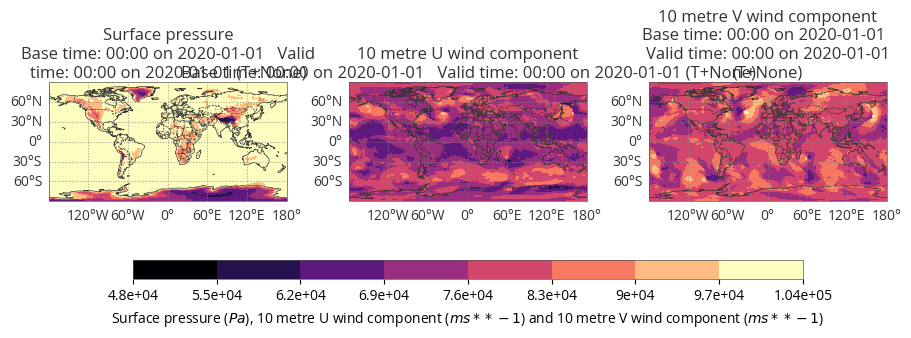

In [21]:
data = earthkit.data.from_source("file", filename)
data.ls
earthkit.maps.quickplot(data)

import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action = "ignore", category = RuntimeWarning)

In [22]:
data.ls
data_array=data.to_xarray(engine="cfgrib")


In [23]:
data_array

<xarray.Dataset> Size: 352MB
Dimensions:            (time: 1, step: 1, surface: 1, values: 12582912,
                        heightAboveGround: 1)
Coordinates:
  * time               (time) datetime64[ns] 8B 2020-01-01
  * step               (step) timedelta64[ns] 8B 00:00:00
  * surface            (surface) float64 8B 0.0
    latitude           (values) float64 101MB ...
    longitude          (values) float64 101MB ...
    valid_time         (time, step) datetime64[ns] 8B ...
  * heightAboveGround  (heightAboveGround) float64 8B 10.0
Dimensions without coordinates: values
Data variables:
    sp                 (time, step, surface, values) float32 50MB ...
    u10                (time, step, heightAboveGround, values) float32 50MB ...
    v10                (time, step, heightAboveGround, values) float32 50MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          1003
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-03-13T09:37 GRIB to CDM+CF via cfgrib-0.9.1...

In [23]:
data_latlon = earthkit.regrid.interpolate(data, out_grid={"grid": [0.1,0.1]}, method="linear")
# Convert data to xarray
snow_390930=data_latlon.to_xarray(engine="cfgrib")
snow=data.to_xarray(engine="cfgrib")

In [24]:
snow


<xarray.Dataset> Size: 352MB
Dimensions:            (time: 1, step: 1, surface: 1, values: 12582912,
                        heightAboveGround: 1)
Coordinates:
  * time               (time) datetime64[ns] 8B 2020-01-01
  * step               (step) timedelta64[ns] 8B 00:00:00
  * surface            (surface) float64 8B 0.0
    latitude           (values) float64 101MB ...
    longitude          (values) float64 101MB ...
    valid_time         (time, step) datetime64[ns] 8B ...
  * heightAboveGround  (heightAboveGround) float64 8B 10.0
Dimensions without coordinates: values
Data variables:
    sp                 (time, step, surface, values) float32 50MB ...
    u10                (time, step, heightAboveGround, values) float32 50MB ...
    v10                (time, step, heightAboveGround, values) float32 50MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          1003
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-03-13T09:35 GRIB to CDM+CF via cfgrib-0.9.1...

In [25]:
# Following two blocks are for RIO calculation, could skip running

In [26]:
shipclass= 'PC5'

def addopenwater(siconcat,sithicat,*argv): # argv could be snthicat
    cww = np.array([1.-np.sum(siconcat)]+[x for x in siconcat])
    hww = np.array([0.]+[x for x in sithicat])
    if len(argv) == 0 :
        return (cww,hww)
    elif len(argv) == 1 :
        sww = np.array([0.]+[x for x in argv[0]])
        return (cww,hww,sww)
    else:
        raise RuntimeError('The function ADDOPENWATER can only be called with 2 or 3 arguments, not with: '+str(len(argv)))

def polaris(dattype,shipclass,season,*argv):
    if dattype == 'mod':
        if not len(argv)==3:
            raise RuntimeError("If DATTYPE is 'mod', then you have to provide 3 additional arguments: CCAT, HCAT and SCAT.")
        else:
            ccat=argv[0]
            hcat=argv[1]
            scat=argv[2]
        if np.sum(ccat) < 0.99:
            raise RuntimeError("The ice concentrations in CCAT does not sum up to 100%. Did you forget to include the open water fraction?")
    if dattype == 'modlim2':
        if not len(argv)==2:
            raise RuntimeError("If DATTYPE is 'modlim2', then you have to provide 2 additional arguments: CCAT and HCAT.")
        else:
            sic=argv[0]
            sit=argv[1]
        if np.sum(sic) < 0.99:
            raise RuntimeError("The ice concentrations in CCAT does not sum up to 100%. Did you forget to include the open water fraction?")
    elif dattype == 'hem':
        if not len(argv)==1:
            raise RuntimeError("If DATTYPE is 'hem', then you have to provide 1 additional argument: THICK")
        else:
            thick = argv[0]
    else:
        raise ValueError("DATTYPE has to be one of ['mod','modlim2','hem']")
                    
    if not (shipclass in ['PC1','PC2','PC3','PC4','PC5','PC6','PC7','1ASuper','1A','1B','1C','noclass']):
        raise ValueError("shipclass has to be one of ['PC1','PC2','PC3','PC4','PC5','PC6','PC7','1ASuper','1A','1B','1C','noclass']")
    # http://joshuakugler.com/archives/30-BetweenDict,-a-Python-dict-for-value-ranges.html
    class BetweenDict(dict):
        def __init__(self, d = {}):
            for k,v in d.items():
                self[k] = v
    
        def lookup(self, key):
            for k, v in self.items():
                if k[0] <= key < k[1]:
                    return v
            warnings.warn("Key '%s' is not between any values in the BetweenDict" % key)
            return {np.nan:np.nan} # Return a dictionary so that rv.lookup(thi[icl])[shipclass] will raise a KeyError.
#AGI            raise KeyError("Key '%s' is not between any values in the BetweenDict" % key)
    
        def setrange(self, key, value):
            try:
                if len(key) == 2:
                    if key[0] < key[1]:
                        dict.__setitem__(self, (key[0], key[1]), value)
                    else:
                        raise RuntimeError('First element of a BetweenDict key '
                                           'must be strictly less than the '
                                           'second element')
                else:
                    raise ValueError('Key of a BetweenDict must be an iterable '
                                     'with length two')
            except TypeError:
                raise TypeError('Key of a BetweenDict must be an iterable '
                                 'with length two')
    
        def __contains__(self, key):
            try:
                return bool(self[key]) or True
            except KeyError:
                return False
    
    # RV summer
    rvs = BetweenDict()
    rvs.setrange([0.  ,0.01],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':3,'PC7':3,  '1ASuper':3,'1A':3,'1B':3,'1C':3,'noclass':3}) # no ice
    rvs.setrange([0.01,0.10],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':2,'PC7':2,  '1ASuper':2,'1A':2,'1B':2,'1C':2,'noclass':1}) # new ice
    rvs.setrange([0.10,0.15],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':2,'PC7':2,  '1ASuper':2,'1A':2,'1B':2,'1C':1,'noclass':0}) # grey ice
    rvs.setrange([0.15,0.30],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':2,'PC7':2,  '1ASuper':2,'1A':2,'1B':1,'1C':0,'noclass':-1}) # grey-white
    rvs.setrange([0.30,0.50],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':2,  'PC6':2,'PC7':1,  '1ASuper':2,'1A':1,'1B':0,'1C':-1,'noclass':-2}) # thin FY 1
    rvs.setrange([0.50,0.70],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':2,  'PC6':1,'PC7':1,  '1ASuper':1,'1A':0,'1B':-1,'1C':-2,'noclass':-3}) # thin FY 2
    rvs.setrange([0.70,0.95],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':2,  'PC6':2,'PC7':1,  '1ASuper':1,'1A':0,'1B':-1,'1C':-2,'noclass':-3}) # medium FY 1
    rvs.setrange([0.95,1.20],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':2,  'PC6':1,'PC7':0,  '1ASuper':0,'1A':-1,'1B':-2,'1C':-3,'noclass':-4}) # medium FY 2
    rvs.setrange([1.20,2.00],{'PC1':2,'PC2':2,'PC3':2,'PC4':1,'PC5':1,  'PC6':0,'PC7':-1,  '1ASuper':-1,'1A':-2,'1B':-3,'1C':-4,'noclass':-5}) # thick FY
    rvs.setrange([2.00,2.50],{'PC1':2,'PC2':1,'PC3':1,'PC4':0,'PC5':-1,  'PC6':-2,'PC7':-3,  '1ASuper':-3,'1A':-4,'1B':-5,'1C':-6,'noclass':-7}) # Second year ice
    rvs.setrange([2.50,3.00],{'PC1':1,'PC2':1,'PC3':0,'PC4':-1,'PC5':-2,  'PC6':-3,'PC7':-3,  '1ASuper':-4,'1A':-5,'1B':-6,'1C':-7,'noclass':-8}) # light MY
    rvs.setrange([3.00,99.9],{'PC1':1,'PC2':0,'PC3':-1,'PC4':-2,'PC5':-2,  'PC6':-3,'PC7':-3,  '1ASuper':-4,'1A':-5,'1B':-6,'1C':-8,'noclass':-8}) # heavy MY
    
    # RV winter
    rvw = BetweenDict()
    rvw.setrange([0.  ,0.01],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':3,'PC7':3,  '1ASuper':3,'1A':3,'1B':3,'1C':3,'noclass':3}) # no ice
    rvw.setrange([0.01,0.10],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':2,'PC7':2,  '1ASuper':2,'1A':2,'1B':2,'1C':2,'noclass':1}) # new ice
    rvw.setrange([0.10,0.15],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':2,'PC7':2,  '1ASuper':2,'1A':2,'1B':2,'1C':1,'noclass':0}) # grey ice
    rvw.setrange([0.15,0.30],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':2,'PC7':2,  '1ASuper':2,'1A':2,'1B':1,'1C':0,'noclass':-1}) # grey-white
    rvw.setrange([0.30,0.50],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':2,  'PC6':2,'PC7':1,  '1ASuper':2,'1A':1,'1B':0,'1C':-1,'noclass':-2}) # thin FY 1
    rvw.setrange([0.50,0.70],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':2,  'PC6':1,'PC7':1,  '1ASuper':1,'1A':0,'1B':-1,'1C':-2,'noclass':-3}) # thin FY 2
    rvw.setrange([0.70,0.95],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':1,  'PC6':1,'PC7':0,  '1ASuper':0,'1A':-1,'1B':-2,'1C':-3,'noclass':-4}) # medium FY 1
    rvw.setrange([0.95,1.20],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':1,  'PC6':0,'PC7':-1,  '1ASuper':-1,'1A':-2,'1B':-3,'1C':-4,'noclass':-5}) # medium FY 2
    rvw.setrange([1.20,2.00],{'PC1':2,'PC2':2,'PC3':2,'PC4':1,'PC5':0,  'PC6':-1,'PC7':-2,  '1ASuper':-2,'1A':-3,'1B':-4,'1C':-5,'noclass':-6}) # thick FY
    rvw.setrange([2.00,2.50],{'PC1':2,'PC2':1,'PC3':1,'PC4':0,'PC5':-1,  'PC6':-2,'PC7':-3,  '1ASuper':-3,'1A':-4,'1B':-5,'1C':-6,'noclass':-7}) # Second year ice
    rvw.setrange([2.50,3.00],{'PC1':1,'PC2':1,'PC3':0,'PC4':-1,'PC5':-2,  'PC6':-3,'PC7':-3,  '1ASuper':-4,'1A':-5,'1B':-6,'1C':-7,'noclass':-8}) # light MY
    rvw.setrange([3.00,99.9],{'PC1':1,'PC2':0,'PC3':-1,'PC4':-2,'PC5':-2,  'PC6':-3,'PC7':-3,  '1ASuper':-4,'1A':-5,'1B':-6,'1C':-8,'noclass':-8}) # heavy MY
    
    if season in ['w','winter']:
        rv = rvw
    elif season in ['s','summer']:
        rv = rvs
    else:
        raise ValueError("season has to be one of ['winter','summer','w','s']")       
   
    if dattype == 'mod':
        # Part for MOD
        ##############
        thi=hcat + scat
        # RIO = (C1xRV1)+(C2xRV2)+(C3xRV3)+...(CnxRVn)
        rio = 0.
        for icl in range(len(ccat)): # 5 model ice categories
            try:
                rio += (10.*ccat[icl]) * rv.lookup(thi[icl])[shipclass] # *10 because C is in ice concentration in tenths.        
            except KeyError: # This happens if POLARIS get a NaN value (because of land grid cells). Then POLARIS's lookup returns an empty dictonary.
                return np.nan # Return NaN to keep land areas masked.
        return rio
 
    elif dattype == 'modlim2':
        # Part for MOD, artificially constructed from LIM2 grid cells
        ###############
        # RIO = (C1xRV1)+(C2xRV2)+(C3xRV3)+...(CnxRVn)
        rio = 0.
        for cellnum in range(len(sic)): # 5 model ice categories
            try:
                rio += (10.*sic[cellnum]) * rv.lookup(sit[cellnum])[shipclass] # *10 because C is in ice concentration in tenths.        
            except KeyError: # This happens if POLARIS get a NaN value (because of land grid cells). Then POLARIS's lookup returns an empty dictonary.
                return np.nan # Return NaN to keep land areas masked.
        return rio
        
    elif dattype == 'hem':
        # Part for HEM
        ###############
        binspolaris=[0.,0.01,0.10,0.15,0.30,0.50,0.70,0.95,1.20,2.00,2.50,3.00,99.9]
        hemdistpol = np.histogram(thick,bins=binspolaris)[0]
        hemconc = hemdistpol/float(np.sum(hemdistpol))
        rio = 0.
        for icl in range(0,len(binspolaris)-1): # 12 POLARIS ice types (not ship classes)
            binthick = binspolaris[icl]+0.001
            rio += (10.*hemconc[icl]) * rv.lookup(binthick)[shipclass] # *10 because C is in ice concentration in tenths
        return rio    




In [27]:
siconc=np.ma.array(siconc,mask=siconc<0.)
sithick=np.ma.array(sithick,mask=siconc<0.)
cputime = time.time()
sic=siconc[:,:]
sit=sithick[:,:]
shipclassmem = shipclass

riotoplot = np.nan*np.zeros([siconc.shape[0]-2,siconc.shape[1]-2])

for jj in range(1,siconc.shape[0]-1):
    for ji in range(1,siconc.shape[1]-1):
        sic9 = 1./9.*sic[jj-1:jj+2,ji-1:ji+2].ravel() # 9 adjacent values
        sit9 = sit[jj-1:jj+2,ji-1:ji+2].ravel() # 9 adjacent values
        if sic9.mask.all():
            riotoplot[jj-1,ji-1]=np.nan
# This does not work with the blue open water colour               elif sic9.sum() <=0.:
#                    riotoplot[jj-1,ji-1]=30.
        else:
            (plotcww, plothww) = addopenwater(sic9,sit9)        
            riotoplot[jj-1,ji-1]=polaris('modlim2',shipclass,'w',plotcww,plothww)
        
lonrio = lon[1:-1,1:-1]
latrio = lat[1:-1,1:-1]        
print( "Time to calculate RIO: ",str(time.time()-cputime))  


# Save each array to its own .npy file
np.save("riotoplot_"+str(sic_391230.time[0].values)[0:10]+".npy", riotoplot)
np.save("lonrio_grib.npy", lonrio)
np.save("latrio_grib.npy", latrio)

print("Data saved as riotoplot_"+str(sic_391230.time[0].values)[0:10]+".npy, lonrio.npy, and latrio.npy")



NameError: name 'siconc' is not defined

In [ ]:
riotoplot=np.load("riotoplot_2039-12-30.npy")
lonrio=np.load("lonrio_grib.npy")
latrio=np.load("latrio_grib.npy")

In [ ]:
shipclass= 'PC5'

riomapAGI = LinearSegmentedColormap.from_list('riomap', [(0. , 'red'),
                                                    (   0.3, 'red'),
                                                    (   0.5, 'yellow'),
                                                    (   0.7, 'green'),
                                                    (    1., 'green')])
                                                    
riomapAGI2 = LinearSegmentedColormap.from_list('riomap', [(0. , 'red'),
                                                (   0.0001, 'yellow'),
                                                (   0.5, 'yellow'),
                                                (   0.5001, 'lightgreen' ),
                                                (   0.9, 'green' ),
                                                (    1., (0.0,0.45,0.45))])                                                      
# Ice concentration
cdict1 = {'red':   ((0.0, 181./255.,181./255.),
               (0.25, 0.2, 0.2),
               (0.5, 0.2, 0.2),
               (1.0, 1.0, 1.0)),
     'green': ((0.0, 238./255, 238./255),
               (0.25, 0.2, 0.2),
               (0.5, 0.2, 0.2),
               (1.0, 1.0, 1.0)),
     'blue':  ((0.0, 1.0, 1.0),
               (0.25, 1.0, 1.0),
               (0.5, 0.2, 0.2),
               (1.0, 1.0, 1.0))
    }
eismapAGI = LinearSegmentedColormap('eismap', cdict1)   
############################################

jifrom = 0
jito = -1


plt.figure(18,figsize=(11,8))
plt.clf()

#m = Basemap(projection='laea', width =5000*400, height=5000*200, lat_ts=81., lat_0=81.05, lon_0=9.2, resolution='i')  resolution: c l i h f
#m = Basemap(projection='npstere',boundinglat=50,lon_0=0,resolution='c')
#Reapply mask:
datatoplot = np.ma.array(riotoplot[:,jifrom:jito],mask=np.isnan(riotoplot[:,jifrom:jito]))  
lontoplot = lonrio[:,jifrom:jito]
lontoplot = np.where(lontoplot > 180, lontoplot - 360, lontoplot)

lattoplot = latrio[:,jifrom:jito]
print('lonshape:',lontoplot.shape)
print('lonmin:',lontoplot.min())
print('lonmax:',lontoplot.max())
print('latshape:',lattoplot.shape)
print('latmin:',lattoplot.min())
print('llatmax:',lattoplot.max())
ax = plt.axes(projection=ccrs.Orthographic(central_longitude=0.0, central_latitude=90, globe=None))
ax.set_extent([-180, 180, 65, 90], crs=ccrs.PlateCarree())# Set the desired geographic extent
parallels = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.5,color='black',alpha=1,linestyle='--')
parallels.ylocator = plt.FixedLocator(range(40, 90, 10))
parallels.xlocator = plt.FixedLocator(range(-180, 180, 30))
parallels.xlabel_style = {'fontsize': 16}
parallels.ylabel_style = {'fontsize': 16}
parallels.top_labels = False
pcolorhandle2 = ax.pcolormesh(lontoplot, lattoplot, datatoplot, zorder=2,cmap=riomapAGI2,vmin=-10,vmax=10,transform=ccrs.PlateCarree(),linewidth=0,rasterized=True)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.COASTLINE)
cbar = plt.colorbar(pcolorhandle2, shrink=0.7, pad=0.1, aspect=15, extend='both')
cbar.ax.tick_params(labelsize=16)
cbar.set_label('RIO', fontsize=16)
plt.text(2750000,-2500000,'Generated using\nDestination Earth\nforecast data',fontsize=11)    

                
#datatoplot = np.ma.array(riotoplot,mask=np.isnan(riotoplot))            
#lontoplot=lon
#lattoplot=lat

#Plot     
#                pcolorhandle1 = plt.pcolormesh(elonplot,elatplot,tmaskori[2:-2,2:-2],zorder=2, rasterized=True,cmap=eismapAGI)  #zorder 2 heisst, dass es NACH dem HAMSOM patch geplottet werden soll dass es NACH dem HAMSOM patch geplottet werden soll
# Extract year, month, and day

plt.title('Ship class: '+shipclass+', Forecast for 2039-12-30')
plt.savefig('DestineE_RIO_'+shipclass+'-for-2039-12-30.pdf', dpi=None, facecolor='w', edgecolor='w', format='pdf',transparent=False,  pad_inches=0.1, bbox_inches='tight')
